<a href="https://colab.research.google.com/github/TharinduLakshimal/IT3133ReactProject/blob/main/7_15_3500_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# This creates a new folder in your Drive called "YOLO_Project"
# (You can change the name to whatever you want)
%mkdir /content/drive/MyDrive/Final_Project

# This moves your Colab terminal INTO that folder
%cd /content/drive/MyDrive/Final_Project

/content/drive/MyDrive/Final_Project


In [5]:
!pip install ultralytics roboflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.2 MB/s eta 0:00:00


In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="uwXX0JgH0syUfCz3yEa1")
project = rf.workspace("tharindus-workspace-b7nsk").project("hazard_detection_research_final")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hazard_detection_research_final-1 in yolov11:: 100%|██████████| 7059/7059 [01:08<00:00, 102.68it/s]


In [7]:
from ultralytics import YOLO

# 1. Load the YOLOv8 Small model
model = YOLO("yolov8s.pt")

# 2. Start training
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=30,
    project="/content/drive/MyDrive/Final_Project/runs", # Keeps everything organized in your Drive
    name="hazard_detection_yolov8_50"                      # Clear name for your run
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, fo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cc0d7293fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [8]:
import os
from ultralytics import YOLO

# 1. Load your best trained weights from Google Drive
model_path = "/content/drive/MyDrive/Final_Project/runs/hazard_detection_yolov8_50/weights/best.pt"
model = YOLO(model_path)

# 2. Automatically locate your dataset test images folder
# (Uses the dataset path variable from your Roboflow download)
test_images_path = os.path.join(dataset.location, "test", "images")

# 3. Run predictions on the test folder
results = model.predict(
    source=test_images_path,
    imgsz=640,
    conf=0.25,                                           # Only show detections with >25% confidence
    save=True,                                           # Save the images with bounding boxes drawn on them
    project="/content/drive/MyDrive/Final_Project/runs", # Save folder location
    name="test_predictions"                              # Folder name for this specific test
)

print("Testing complete! Visual results saved in your Google Drive.")


image 1/540 /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/images/brown_carpet_black_no_sound_VID_20260612_184737_f0_jpg.rf.765d10255d51d9d9975efde407598dd0.jpg: 640x640 (no detections), 16.2ms
image 2/540 /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/images/brown_carpet_black_no_sound_VID_20260612_184737_f1_jpg.rf.7842267f5f57430d7c700b480bb91784.jpg: 640x640 (no detections), 16.2ms
image 3/540 /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/images/brown_carpet_black_no_sound_VID_20260612_184737_f2_jpg.rf.88d8c53141ec9c60abaf18f453347cd4.jpg: 640x640 (no detections), 16.1ms
image 4/540 /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/images/brown_carpet_black_no_sound_VID_20260612_184737_f3_jpg.rf.1d489d6103dd99cb9f73f7b825434290.jpg: 640x640 (no detections), 16.1ms
image 5/540 /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/images/brown_carpet

In [9]:
from ultralytics import YOLO

# 1. Load your trained model
model_path = "/content/drive/MyDrive/Final_Project/runs/hazard_detection_yolov8_50/weights/best.pt"
model = YOLO(model_path)

# 2. Evaluate the model specifically on the "test" folder
metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    split="test",                                        # This is the magic word that tells it to use the test folder
    project="/content/drive/MyDrive/Final_Project/runs",
    name="test_evaluation_metrics"                       # Saves all graphs in a new folder
)

# 3. Print out your final scores!
print("--- TEST SET RESULTS ---")
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 3.6±4.7 ms, read: 3.3±1.9 MB/s, size: 22.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/labels... 540 images, 143 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 540/540 93.7it/s 5.8s
val: New cache created: /content/drive/MyDrive/Final_Project/hazard_detection_research_final-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.1it/s 11.1s
                   all        540        917      0.789      0.731      0.773      0.408
           shard_clear        279        637      0.761      0.728      0.768      0.432
 

In [10]:
import cv2
import os
import shutil
import glob
import yaml

# 1. Define your paths (Make sure these match your current Drive setup)
original_dataset_dir = dataset.location # Or type your specific path like "/content/drive/MyDrive/YOLO_Project/hazard_detection_research_final-1"
new_dataset_dir = "/content/drive/MyDrive/Final_Project/dataset_enhanced"

# Create the CLAHE object
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

# 2. Process each folder (train, valid, test)
for split in ['train', 'valid', 'test']:
    print(f"Processing {split} set...")

    # Create new directories for images and labels
    os.makedirs(os.path.join(new_dataset_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(new_dataset_dir, split, 'labels'), exist_ok=True)

    # Get all original images
    img_paths = glob.glob(os.path.join(original_dataset_dir, split, 'images', '*.jpg'))

    for img_path in img_paths:
        # A. Read image
        img = cv2.imread(img_path)

        # B. Convert to Grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # C. Apply CLAHE to boost contrast of glass edges
        enhanced_gray = clahe.apply(gray)

        # D. Convert back to 3-channels (YOLO expects 3 color channels, even if it's black and white)
        enhanced_img = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2BGR)

        # E. Save new image
        filename = os.path.basename(img_path)
        new_img_path = os.path.join(new_dataset_dir, split, 'images', filename)
        cv2.imwrite(new_img_path, enhanced_img)

        # F. Copy the corresponding label file over
        label_filename = filename.replace('.jpg', '.txt')
        orig_label = os.path.join(original_dataset_dir, split, 'labels', label_filename)
        new_label = os.path.join(new_dataset_dir, split, 'labels', label_filename)
        if os.path.exists(orig_label):
            shutil.copy(orig_label, new_label)

# 3. Create a new data.yaml file for the enhanced dataset
data_yaml = {
    'train': os.path.join(new_dataset_dir, 'train', 'images'),
    'val': os.path.join(new_dataset_dir, 'valid', 'images'),
    'test': os.path.join(new_dataset_dir, 'test', 'images'),
    'nc': 2,
    'names': ['shard_clear', 'shard_colored']
}

yaml_path = os.path.join(new_dataset_dir, 'data_enhanced.yaml')
with open(yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print(f"Done! Enhanced dataset saved to {new_dataset_dir}")
print(f"New YAML file created at {yaml_path}")

Processing train set...
Processing valid set...
Processing test set...
Done! Enhanced dataset saved to /content/drive/MyDrive/Final_Project/dataset_enhanced
New YAML file created at /content/drive/MyDrive/Final_Project/dataset_enhanced/data_enhanced.yaml


In [11]:
from ultralytics import YOLO

# Load a fresh YOLOv8 model
model_enhanced = YOLO("yolov8s.pt")

# Train using the newly created enhanced dataset
model_enhanced.train(
    data="/content/drive/MyDrive/Final_Project/dataset_enhanced/data_enhanced.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=30,
    project="/content/drive/MyDrive/Final_Project/runs",
    name="hazard_detection_enhanced_yolov8_50"
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Final_Project/dataset_enhanced/data_enhanced.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hazard_detection_enhanced_yolov8_50, nbs=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cc1d7149d60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [13]:
from ultralytics import YOLO

# 1. Load your newly trained enhanced weights
enhanced_model_path = "/content/drive/MyDrive/Final_Project/runs/hazard_detection_enhanced_yolov8_50/weights/best.pt"
model = YOLO(enhanced_model_path)

# 2. Evaluate the model specifically on the enhanced "test" folder
metrics = model.val(
    data="/content/drive/MyDrive/Final_Project/dataset_enhanced/data_enhanced.yaml",
    split="test",                                        # Forces it to evaluate the unseen test split
    project="/content/drive/MyDrive/Final_Project/runs",
    name="test_evaluation_enhanced"                      # Saves graphs into a dedicated folder
)

# 3. Print out the final enhanced test scores
print("\n--- ENHANCED TEST SET RESULTS ---")
print(f"Test mAP50: {metrics.box.map50:.3f}")
print(f"Test Precision: {metrics.box.p.mean():.3f}")
print(f"Test Recall: {metrics.box.r.mean():.3f}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 16.5±4.6 MB/s, size: 57.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Final_Project/dataset_enhanced/test/labels... 540 images, 143 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 540/540 82.3it/s 6.6s
val: New cache created: /content/drive/MyDrive/Final_Project/dataset_enhanced/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.6it/s 9.5s
                   all        540        917      0.724      0.604      0.661      0.329
           shard_clear        279        637      0.735      0.655      0.704      0.391
         shard_colored        118  

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os
import shutil
import glob

# 1. Paths
original_dir = "/content/drive/MyDrive/Final_Project/hazard_detection_research_final-1"
new_dataset_dir = "/content/drive/MyDrive/Final_Project/hazard_detection_with_backgrounds"

print("Creating a new folder copy and fixing background images...")

# 2. Loop through splits to copy and fix
for split in ['train', 'valid', 'test']:
    orig_images_path = os.path.join(original_dir, split, 'images')
    orig_labels_path = os.path.join(original_dir, split, 'labels')

    new_images_path = os.path.join(new_dataset_dir, split, 'images')
    new_labels_path = os.path.join(new_dataset_dir, split, 'labels')

    # Create the new destination directories
    os.makedirs(new_images_path, exist_ok=True)
    os.makedirs(new_labels_path, exist_ok=True)

    # Copy all original images over to the new folder
    image_files = glob.glob(os.path.join(orig_images_path, '*.*'))
    for img_file in image_files:
        filename = os.path.basename(img_file)
        shutil.copy(img_file, os.path.join(new_images_path, filename))

        # If an original label exists, copy it too
        base_name = os.path.splitext(filename)[0]
        orig_label_file = os.path.join(orig_labels_path, f"{base_name}.txt")
        new_label_file = os.path.join(new_labels_path, f"{base_name}.txt")

        if os.path.exists(orig_label_file):
            shutil.copy(orig_label_file, new_label_file)

    # Now, scan the NEW folder and create blank .txt files for the background images
    new_image_files = glob.glob(os.path.join(new_images_path, '*.*'))
    fix_count = 0
    for img_file in new_image_files:
        base_name = os.path.splitext(os.path.basename(img_file))[0]
        label_file = os.path.join(new_labels_path, f"{base_name}.txt")

        if not os.path.exists(label_file):
            with open(label_file, 'w') as f:
                pass # Create blank 0-byte file
            fix_count += 1

    print(f"-> {split} split setup complete! Added {fix_count} blank background labels.")

# 3. Create an updated data.yaml file inside the new folder pointing to the new paths
import yaml
data_yaml = {
    'train': os.path.join(new_dataset_dir, 'train', 'images'),
    'val': os.path.join(new_dataset_dir, 'valid', 'images'),
    'test': os.path.join(new_dataset_dir, 'test', 'images'),
    'nc': 2,
    'names': ['shard_clear', 'shard_colored']
}

new_yaml_path = os.path.join(new_dataset_dir, 'data.yaml')
with open(new_yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print(f"\nSuccess! Copy created at: {new_dataset_dir}")
print(f"New YAML configuration built at: {new_yaml_path}")

Creating a new folder copy and fixing background images...
-> train split setup complete! Added 0 blank background labels.
-> valid split setup complete! Added 0 blank background labels.
-> test split setup complete! Added 0 blank background labels.

Success! Copy created at: /content/drive/MyDrive/Final_Project/hazard_detection_with_backgrounds
New YAML configuration built at: /content/drive/MyDrive/Final_Project/hazard_detection_with_backgrounds/data.yaml


In [16]:
import cv2
import os
import shutil
import glob
import yaml
import numpy as np

# 1. Paths
original_dir = "/content/drive/MyDrive/Final_Project/hazard_detection_research_final-1"
glint_dataset_dir = "/content/drive/MyDrive/Final_Project/hazard_detection_glint_boost"

print("Applying Glint Enhancement and Edge Sharpening to dataset...")

# Function to enhance glints and sharpen edges
def enhance_glint_and_edges(image):
    # Apply Unsharp Masking to boost edges and light reflections (glints)
    # This keeps the original colors but makes the sharp glass features "pop"
    gaussian_blur = cv2.GaussianBlur(image, (0, 0), 2.0)
    sharpened = cv2.addWeighted(image, 1.5, gaussian_blur, -0.5, 0)
    return sharpened

# 2. Process each folder
for split in ['train', 'valid', 'test']:
    orig_images_path = os.path.join(original_dir, split, 'images')
    orig_labels_path = os.path.join(original_dir, split, 'labels')

    new_images_path = os.path.join(glint_dataset_dir, split, 'images')
    new_labels_path = os.path.join(glint_dataset_dir, split, 'labels')

    os.makedirs(new_images_path, exist_ok=True)
    os.makedirs(new_labels_path, exist_ok=True)

    image_files = glob.glob(os.path.join(orig_images_path, '*.*'))

    for img_file in image_files:
        filename = os.path.basename(img_file)

        # Read, filter, and save the image
        img = cv2.imread(img_file)
        enhanced_img = enhance_glint_and_edges(img)
        cv2.imwrite(os.path.join(new_images_path, filename), enhanced_img)

        # Copy the labels (including the blank background ones we already fixed!)
        base_name = os.path.splitext(filename)[0]
        orig_label_file = os.path.join(orig_labels_path, f"{base_name}.txt")
        new_label_file = os.path.join(new_labels_path, f"{base_name}.txt")

        if os.path.exists(orig_label_file):
            shutil.copy(orig_label_file, new_label_file)

    print(f"-> Filter applied to {split} split.")

# 3. Create the YAML file
data_yaml = {
    'train': os.path.join(glint_dataset_dir, 'train', 'images'),
    'val': os.path.join(glint_dataset_dir, 'valid', 'images'),
    'test': os.path.join(glint_dataset_dir, 'test', 'images'),
    'nc': 2,
    'names': ['shard_clear', 'shard_colored']
}

new_yaml_path = os.path.join(glint_dataset_dir, 'data.yaml')
with open(new_yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print(f"\nSuccess! Glint Enhanced dataset saved to: {glint_dataset_dir}")

Applying Glint Enhancement and Edge Sharpening to dataset...
-> Filter applied to train split.
-> Filter applied to valid split.
-> Filter applied to test split.

Success! Glint Enhanced dataset saved to: /content/drive/MyDrive/Final_Project/hazard_detection_glint_boost


In [17]:
from ultralytics import YOLO

# 1. Load a fresh YOLOv8 Small model
model = YOLO("yolov8s.pt")

# 2. Point to your NEW Glint-Enhanced data.yaml file
yaml_path = "/content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/data.yaml"

# 3. Start training
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,           # Ensures it uses the GPU
    workers=2,
    patience=30,
    project="/content/drive/MyDrive/Final_Project/runs",
    name="hazard_detection_glint_boost_run"  # Saves results under a specific name for comparison
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hazard_detection_glint_boost_run, nbs=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cc10c296630>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [18]:
from ultralytics import YOLO

# 1. Load your newly trained Glint-Enhanced weights
glint_model_path = "/content/drive/MyDrive/Final_Project/runs/hazard_detection_glint_boost_run/weights/best.pt"
model = YOLO(glint_model_path)

# 2. Evaluate the model specifically on the glint-boosted "test" folder
metrics = model.val(
    data="/content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/data.yaml",
    split="test",                                        # This forces it to use the test set
    project="/content/drive/MyDrive/Final_Project/runs",
    name="test_evaluation_glint_boost"                   # Saves results in a dedicated folder
)

# 3. Print out the final Glint-Enhanced test scores
print("\n--- GLINT-BOOSTED TEST SET RESULTS ---")
print(f"Test mAP50: {metrics.box.map50:.3f}")
print(f"Test Precision: {metrics.box.p.mean():.3f}")
print(f"Test Recall: {metrics.box.r.mean():.3f}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.2 ms, read: 11.3±4.5 MB/s, size: 44.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/test/labels... 540 images, 143 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 540/540 77.1it/s 7.0s
val: New cache created: /content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.5it/s 9.6s
                   all        540        917      0.829      0.728      0.784      0.415
           shard_clear        279        637      0.815      0.703      0.771      0.437
         sh

Running YOLO predictions to count detections per image...

=== PER GROUP DETECTION RESULTS ===

Glass Type             Floor Type  Images  Total Detections  Avg per Image
     Brown           Carpet Black      10                 6       0.600000
      Bulb           Carpet Black      10                21       2.100000
     Clean           Carpet Black      15                20       1.333333
     Green           Carpet Black       5                19       3.800000
    Mirror           Carpet Black      10                18       1.800000
      Bulb           Cement Black      15                41       2.733333
     Clean           Cement Black      15                49       3.266667
    Mirror           Cement Black      10                31       3.100000
     Brown   Cement Black Nosound      10                 9       0.900000
      Bulb   Cement Black Nosound       5                 3       0.600000
     Clean   Cement Black Nosound       5                 6       1.200000
    

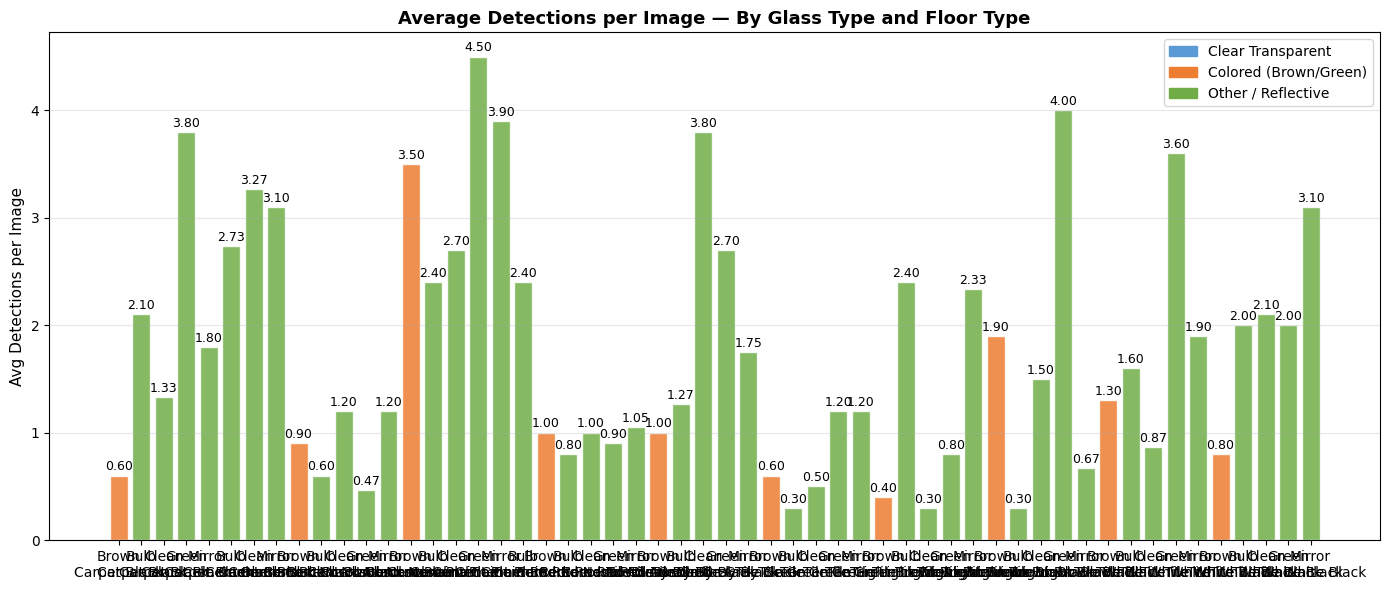

✅ Saved Chart: /content/drive/MyDrive/Final_Project/runs/per_group_chart.png


In [19]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from ultralytics import YOLO

# --- 1. CONFIGURATION PATHS ---
# Point to your Glint-Boosted test images and best model
TEST_IMAGES_DIR = "/content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/test/images"
MODEL_PATH = "/content/drive/MyDrive/Final_Project/runs/hazard_detection_glint_boost_run/weights/best.pt"
RUNS_DIR = "/content/drive/MyDrive/Final_Project/runs"

os.makedirs(RUNS_DIR, exist_ok=True)

# --- 2. FILENAME PARSER ---
def parse_filename(filename):
    """
    Extracts Glass Type and Floor Type from filenames like:
    brown_carpet_black_no_sound_VID_20260612_184737_f0.jpg
    """
    name = filename.split('.')[0] # Remove .jpg
    parts = name.split('_')

    # 1st part is the glass type (e.g., 'brown', 'clear')
    glass_type = parts[0]

    # Extract floor type (everything between glass type and 'no_sound' or 'VID')
    floor_parts = []
    for part in parts[1:]:
        if part in ['no', 'sound', 'VID']:
            break
        floor_parts.append(part)

    floor_type = "_".join(floor_parts) if floor_parts else "unknown_floor"

    return glass_type, floor_type

# --- 3. RUN INFERENCE & GATHER DATA ---
print("Running YOLO predictions to count detections per image...")
model = YOLO(MODEL_PATH)
results = model.predict(source=TEST_IMAGES_DIR, conf=0.25, verbose=False)

group_results = {}

for r in results:
    filename = os.path.basename(r.path)
    glass, floor = parse_filename(filename)
    group_key = f"{glass}__{floor}"

    if group_key not in group_results:
        group_results[group_key] = {'images': 0, 'detections': 0}

    group_results[group_key]['images'] += 1
    group_results[group_key]['detections'] += len(r.boxes) # Count number of bounding boxes found

# Calculate averages
for k in group_results:
    if group_results[k]['images'] > 0:
        group_results[k]['avg_per_img'] = group_results[k]['detections'] / group_results[k]['images']
    else:
        group_results[k]['avg_per_img'] = 0

# --- 4. FORMAT DATAFRAME ---
rows = []
for group, r in group_results.items():
    glass, floor = group.split('__')
    rows.append({
        'Glass Type'       : glass.capitalize(),
        'Floor Type'       : floor.replace('_', ' ').title(),
        'Images'           : r['images'],
        'Total Detections' : r['detections'],
        'Avg per Image'    : r['avg_per_img']
    })

df = pd.DataFrame(rows).sort_values(['Floor Type', 'Glass Type'])
print('\n=== PER GROUP DETECTION RESULTS ===\n')
print(df.to_string(index=False))

csv_path = os.path.join(RUNS_DIR, 'per_group_results.csv')
df.to_csv(csv_path, index=False)
print(f'\n✅ Saved CSV: {csv_path}')

# --- 5. GENERATE CHART ---
fig, ax = plt.subplots(figsize=(14, 6))
labels = [f"{r['Glass Type']}\n{r['Floor Type']}" for _, r in df.iterrows()]
values = df['Avg per Image'].tolist()

# Dynamic colors based on the parsed Glass Type
colors = []
for l in labels:
    glass_str = l.split('\n')[0].lower()
    if 'clear' in glass_str or 'transparent' in glass_str:
        colors.append('#5B9BD5') # Blue for clear
    elif 'brown' in glass_str or 'colored' in glass_str:
        colors.append('#ED7D31') # Orange for colored
    else:
        colors.append('#70AD47') # Green for reflective/other

bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Average Detections per Image — By Glass Type and Floor Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Detections per Image', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value text on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

# Build Legend
legend_elements = [
    Patch(color='#5B9BD5', label='Clear Transparent'),
    Patch(color='#ED7D31', label='Colored (Brown/Green)'),
    Patch(color='#70AD47', label='Other / Reflective')
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
save_path = os.path.join(RUNS_DIR, 'per_group_chart.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved Chart: {save_path}')

Running YOLO predictions to gather detection data...

=== 1. OVERALL GLASS TYPE COMPARISON ===


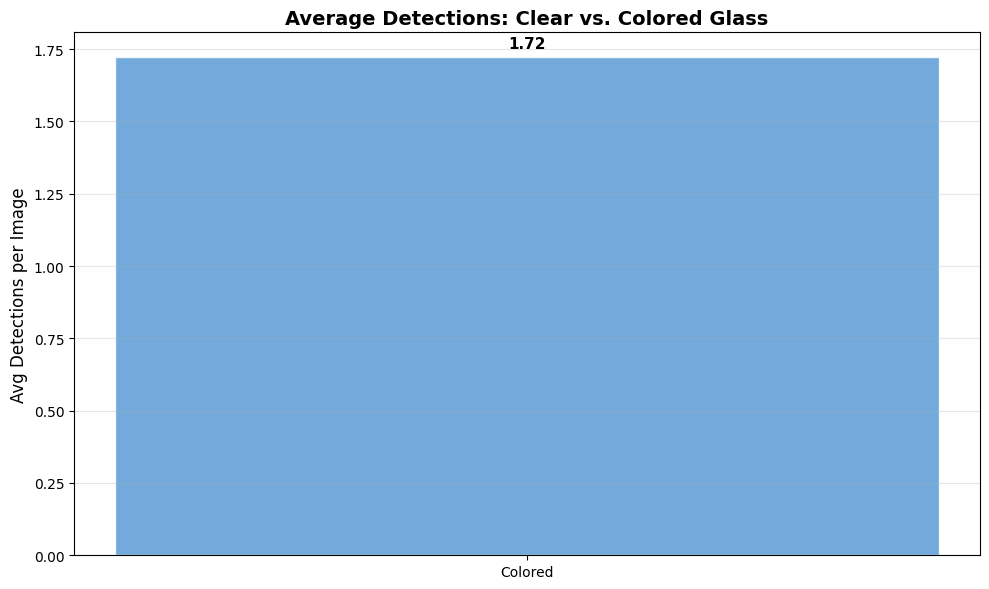

✅ Saved Chart: /content/drive/MyDrive/Final_Project/runs/summary_glass_type.png

=== 2. OVERALL FLOOR TYPE COMPARISON ===


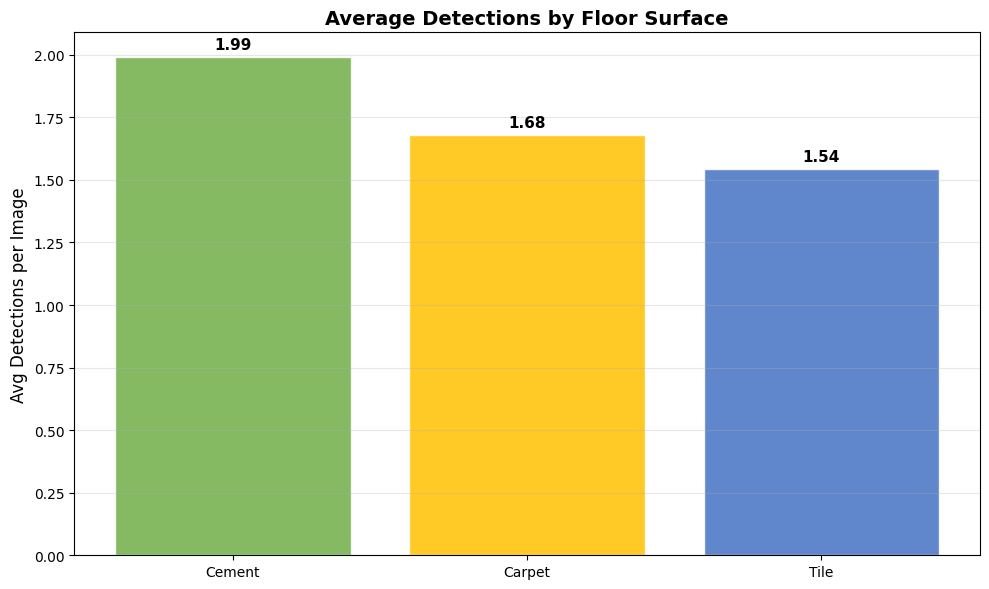

✅ Saved Chart: /content/drive/MyDrive/Final_Project/runs/summary_floor_type.png

=== 3. DETAILED GROUP COMBINATIONS ===


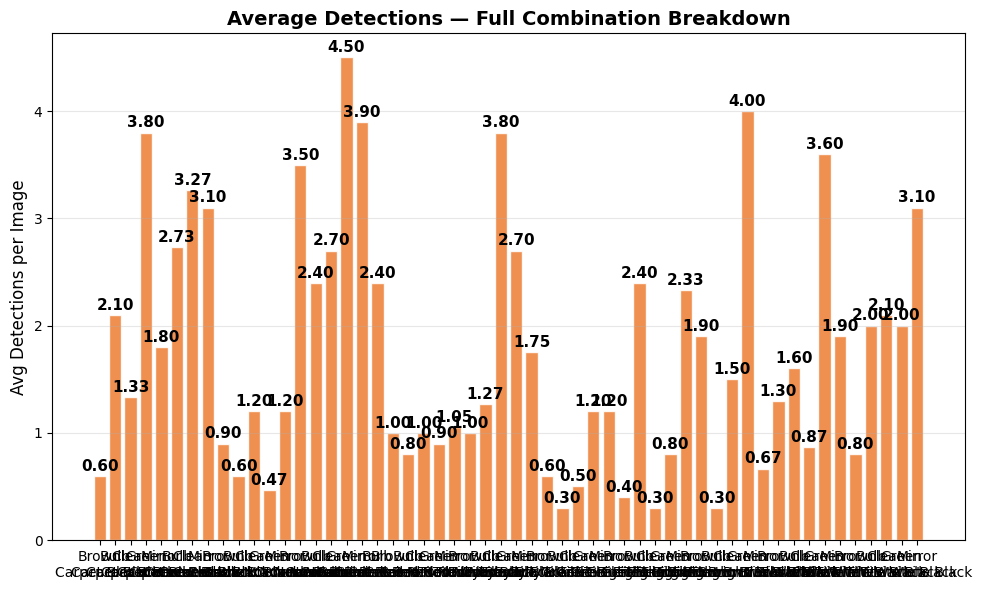

✅ Saved Chart: /content/drive/MyDrive/Final_Project/runs/detailed_combination_chart.png

✅ Saved Raw Data CSV: /content/drive/MyDrive/Final_Project/runs/full_image_data.csv


In [20]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from ultralytics import YOLO

# --- 1. CONFIGURATION PATHS ---
TEST_IMAGES_DIR = "/content/drive/MyDrive/Final_Project/hazard_detection_glint_boost/test/images"
MODEL_PATH = "/content/drive/MyDrive/Final_Project/runs/hazard_detection_glint_boost_run/weights/best.pt"
RUNS_DIR = "/content/drive/MyDrive/Final_Project/runs"

os.makedirs(RUNS_DIR, exist_ok=True)

# --- 2. FILENAME PARSER ---
def parse_filename(filename):
    """
    Extracts specific and broad categories from filenames.
    """
    name = filename.split('.')[0]
    parts = name.split('_')

    # Specifics
    glass_specific = parts[0]
    floor_parts = []
    for part in parts[1:]:
        if part in ['no', 'sound', 'VID']:
            break
        floor_parts.append(part)
    floor_specific = "_".join(floor_parts) if floor_parts else "unknown_floor"

    # Broad Glass Category (Clear vs Colored)
    if 'clear' in glass_specific.lower() or 'transparent' in glass_specific.lower():
        glass_broad = 'Clear'
    else:
        glass_broad = 'Colored'

    # Broad Floor Category (Cement vs Tile vs Carpet)
    floor_lower = floor_specific.lower()
    if 'carpet' in floor_lower:
        floor_broad = 'Carpet'
    elif 'tile' in floor_lower:
        floor_broad = 'Tile'
    elif 'ciment' in floor_lower or 'cement' in floor_lower:
        floor_broad = 'Cement'
    else:
        floor_broad = 'Other'

    return glass_specific.capitalize(), glass_broad, floor_specific.replace('_', ' ').title(), floor_broad

# --- 3. RUN INFERENCE & GATHER DATA ---
print("Running YOLO predictions to gather detection data...")
model = YOLO(MODEL_PATH)
results = model.predict(source=TEST_IMAGES_DIR, conf=0.25, verbose=False)

rows = []
for r in results:
    filename = os.path.basename(r.path)
    glass_spec, glass_broad, floor_spec, floor_broad = parse_filename(filename)

    rows.append({
        'Filename': filename,
        'Specific Glass': glass_spec,
        'Broad Glass': glass_broad,
        'Specific Floor': floor_spec,
        'Broad Floor': floor_broad,
        'Detections': len(r.boxes)
    })

# Create a master DataFrame
df = pd.DataFrame(rows)

# --- 4. HELPER FUNCTION TO DRAW CHARTS ---
def draw_bar_chart(data_series, title, ylabel, colors, save_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(data_series.index, data_series.values, color=colors, alpha=0.85, edgecolor='white')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    # Add values on top of bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(RUNS_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved Chart: {save_path}')

# --- 5. GENERATE CHART 1: BROAD GLASS TYPE ---
print('\n=== 1. OVERALL GLASS TYPE COMPARISON ===')
glass_avg = df.groupby('Broad Glass')['Detections'].mean()
draw_bar_chart(
    data_series=glass_avg,
    title='Average Detections: Clear vs. Colored Glass',
    ylabel='Avg Detections per Image',
    colors=['#5B9BD5', '#ED7D31'], # Blue for Clear, Orange for Colored
    save_name='summary_glass_type.png'
)

# --- 6. GENERATE CHART 2: BROAD FLOOR TYPE ---
print('\n=== 2. OVERALL FLOOR TYPE COMPARISON ===')
floor_avg = df.groupby('Broad Floor')['Detections'].mean().sort_values(ascending=False)
draw_bar_chart(
    data_series=floor_avg,
    title='Average Detections by Floor Surface',
    ylabel='Avg Detections per Image',
    colors=['#70AD47', '#FFC000', '#4472C4', '#A5A5A5'][:len(floor_avg)],
    save_name='summary_floor_type.png'
)

# --- 7. GENERATE CHART 3: DETAILED COMBINATION ---
print('\n=== 3. DETAILED GROUP COMBINATIONS ===')
# Group by both specific glass and specific floor
detailed_avg = df.groupby(['Specific Floor', 'Specific Glass'])['Detections'].mean().reset_index()
detailed_avg['Label'] = detailed_avg['Specific Glass'] + "\n" + detailed_avg['Specific Floor']

# Set colors based on clear vs colored for the detailed chart
det_colors = ['#5B9BD5' if 'clear' in label.lower() or 'transparent' in label.lower()
              else '#ED7D31' for label in detailed_avg['Label']]

draw_bar_chart(
    data_series=pd.Series(detailed_avg['Detections'].values, index=detailed_avg['Label']),
    title='Average Detections — Full Combination Breakdown',
    ylabel='Avg Detections per Image',
    colors=det_colors,
    save_name='detailed_combination_chart.png'
)

# Save the raw compiled data to CSV for your records
csv_path = os.path.join(RUNS_DIR, 'full_image_data.csv')
df.to_csv(csv_path, index=False)
print(f'\n✅ Saved Raw Data CSV: {csv_path}')


=== OVERALL RESEARCH METRICS TABLE ===

                            Experiment  mAP50  Precision  Recall
         Run 1: Raw Images\n(Baseline)  0.776      0.809   0.711
    Run 2: Grayscale\n(Failed Attempt)  0.648      0.733   0.602
Run 3: Glint-Boosted\n(Successful Fix)  0.784      0.829   0.728

✅ Saved Data Table: /content/drive/MyDrive/Final_Project/runs/overall_experiment_comparison.csv


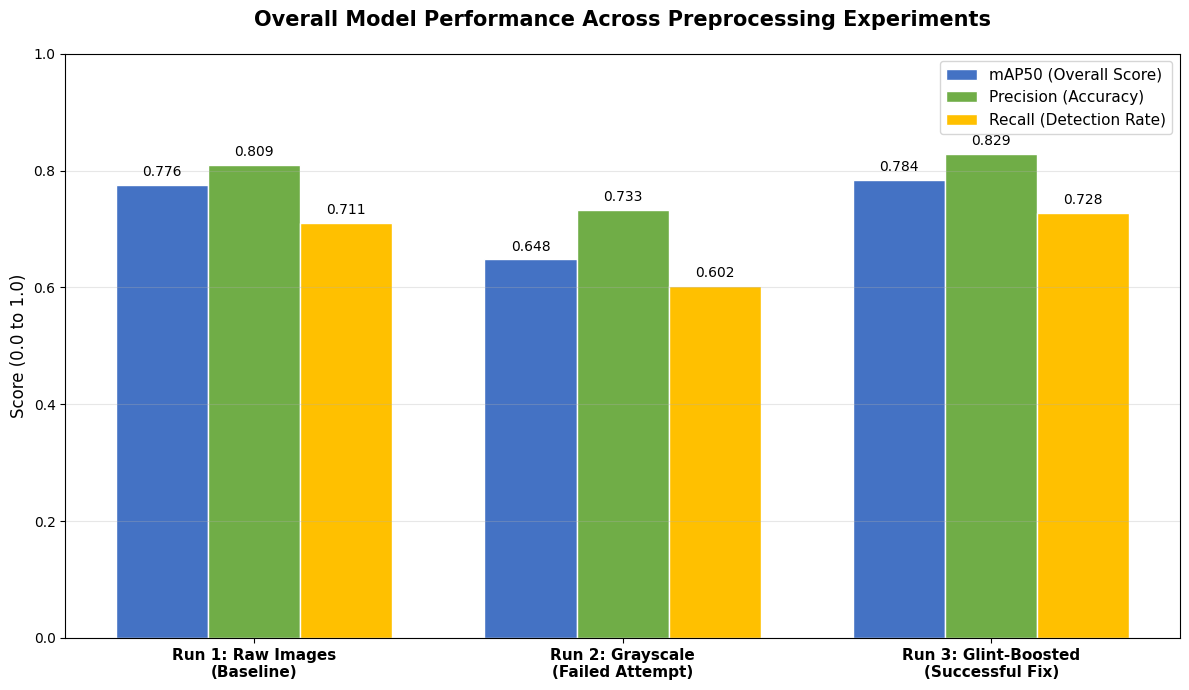

✅ Saved Chart: /content/drive/MyDrive/Final_Project/runs/overall_experiment_chart.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. SETUP PATHS ---
RUNS_DIR = "/content/drive/MyDrive/Final_Project/runs"
os.makedirs(RUNS_DIR, exist_ok=True)

# --- 2. INPUT THE RESEARCH DATA ---
# These are the exact test metrics we gathered from your 3 experiments
data = {
    'Experiment': [
        'Run 1: Raw Images\n(Baseline)',
        'Run 2: Grayscale\n(Failed Attempt)',
        'Run 3: Glint-Boosted\n(Successful Fix)'
    ],
    'mAP50': [0.776, 0.648, 0.784],
    'Precision': [0.809, 0.733, 0.829],
    'Recall': [0.711, 0.602, 0.728]
}

# Create a DataFrame for easy table viewing and saving
df = pd.DataFrame(data)

print('\n=== OVERALL RESEARCH METRICS TABLE ===\n')
print(df.to_string(index=False))

# Save the table as a CSV
csv_path = os.path.join(RUNS_DIR, 'overall_experiment_comparison.csv')
df.to_csv(csv_path, index=False)
print(f'\n✅ Saved Data Table: {csv_path}')

# --- 3. GENERATE THE GROUPED BAR CHART ---
# Set up the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Set bar width and positions
bar_width = 0.25
x = np.arange(len(df['Experiment']))

# Create bars for each metric
bars_map = ax.bar(x - bar_width, df['mAP50'], width=bar_width, label='mAP50 (Overall Score)', color='#4472C4', edgecolor='white')
bars_prec = ax.bar(x, df['Precision'], width=bar_width, label='Precision (Accuracy)', color='#70AD47', edgecolor='white')
bars_rec = ax.bar(x + bar_width, df['Recall'], width=bar_width, label='Recall (Detection Rate)', color='#FFC000', edgecolor='white')

# Add titles and labels
ax.set_title('Overall Model Performance Across Preprocessing Experiments', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df['Experiment'], fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.0) # Metrics are between 0 and 1
ax.grid(axis='y', alpha=0.3)

# Function to add values on top of the bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, rotation=0)

add_labels(bars_map)
add_labels(bars_prec)
add_labels(bars_rec)

# Add Legend
ax.legend(loc='upper right', fontsize=11)

# Save and show
plt.tight_layout()
save_path = os.path.join(RUNS_DIR, 'overall_experiment_chart.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'✅ Saved Chart: {save_path}')